In [116]:
import random
from concurrent.futures import ThreadPoolExecutor

import json
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from importlib import reload
from colorsys import hsv_to_rgb

import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support

from models.simple_classifier import train as T, model as M
from data_readers import data_loader as D, radar as R, infrared as IR, name_map as N

_=reload(D), reload(R), reload(IR), reload(N), reload(T), reload(M)

## data duration plot

In [ ]:
def measure_duration(path):
    n_frames = None
    if isinstance(path, str):
        sample = IR.InfraredData.read_from_path(path)
        n_frames = sample.n_frames
    elif isinstance(path, list):
        sample = R.RadarData.read_from_path(path)
        n_frames = sample.bin(18.7).n_frames
    else:
        print(f"Unknown path type: {type(path)}-{path}")
        return None, None
    return float(sample.timestamps[-1] - sample.timestamps[0]), n_frames

# df = D.find_available_files("../../../RF-Behavior")

# with ThreadPoolExecutor(max_workers=8) as executor:
#     infrared = list(tqdm(executor.map(measure_duration, df.infrared_path.values), total =len(df), desc="Measuring infrared"))

# with ThreadPoolExecutor(max_workers=8) as executor:
#     radar = list(tqdm(executor.map(measure_duration, df.radar_path.values), total =len(df), desc="Measuring radar"))

# df["infrared_duration"] = [x[0] for x in infrared]
# df["infrared_frame_count"] = [x[1] for x in infrared]
# df["radar_duration"] = [x[0] for x in radar]
# df["radar_frame_count"] = [x[1] for x in radar]

Measuring infrared:   0%|          | 0/6330 [00:00<?, ?it/s]

Unknown path type: <class 'float'>
Unknown path type: <class 'float'>
Unknown path type: <class 'float'>


Measuring radar:   0%|          | 0/6330 [00:00<?, ?it/s]

Unknown path type: <class 'float'>
Unknown path type: <class 'float'>


In [3]:
# df.to_csv("./rf_behavior_path_and_duration.csv", index=False)

df = pd.read_csv("./rf_behavior_path_and_duration.csv")
df["radar_path"] = df["radar_path"].apply(lambda x: json.loads(x.replace("'", '"')) if isinstance(x, str) else x)
df["mean_duration"] = df[["infrared_duration", "radar_duration"]].mean(axis=1)

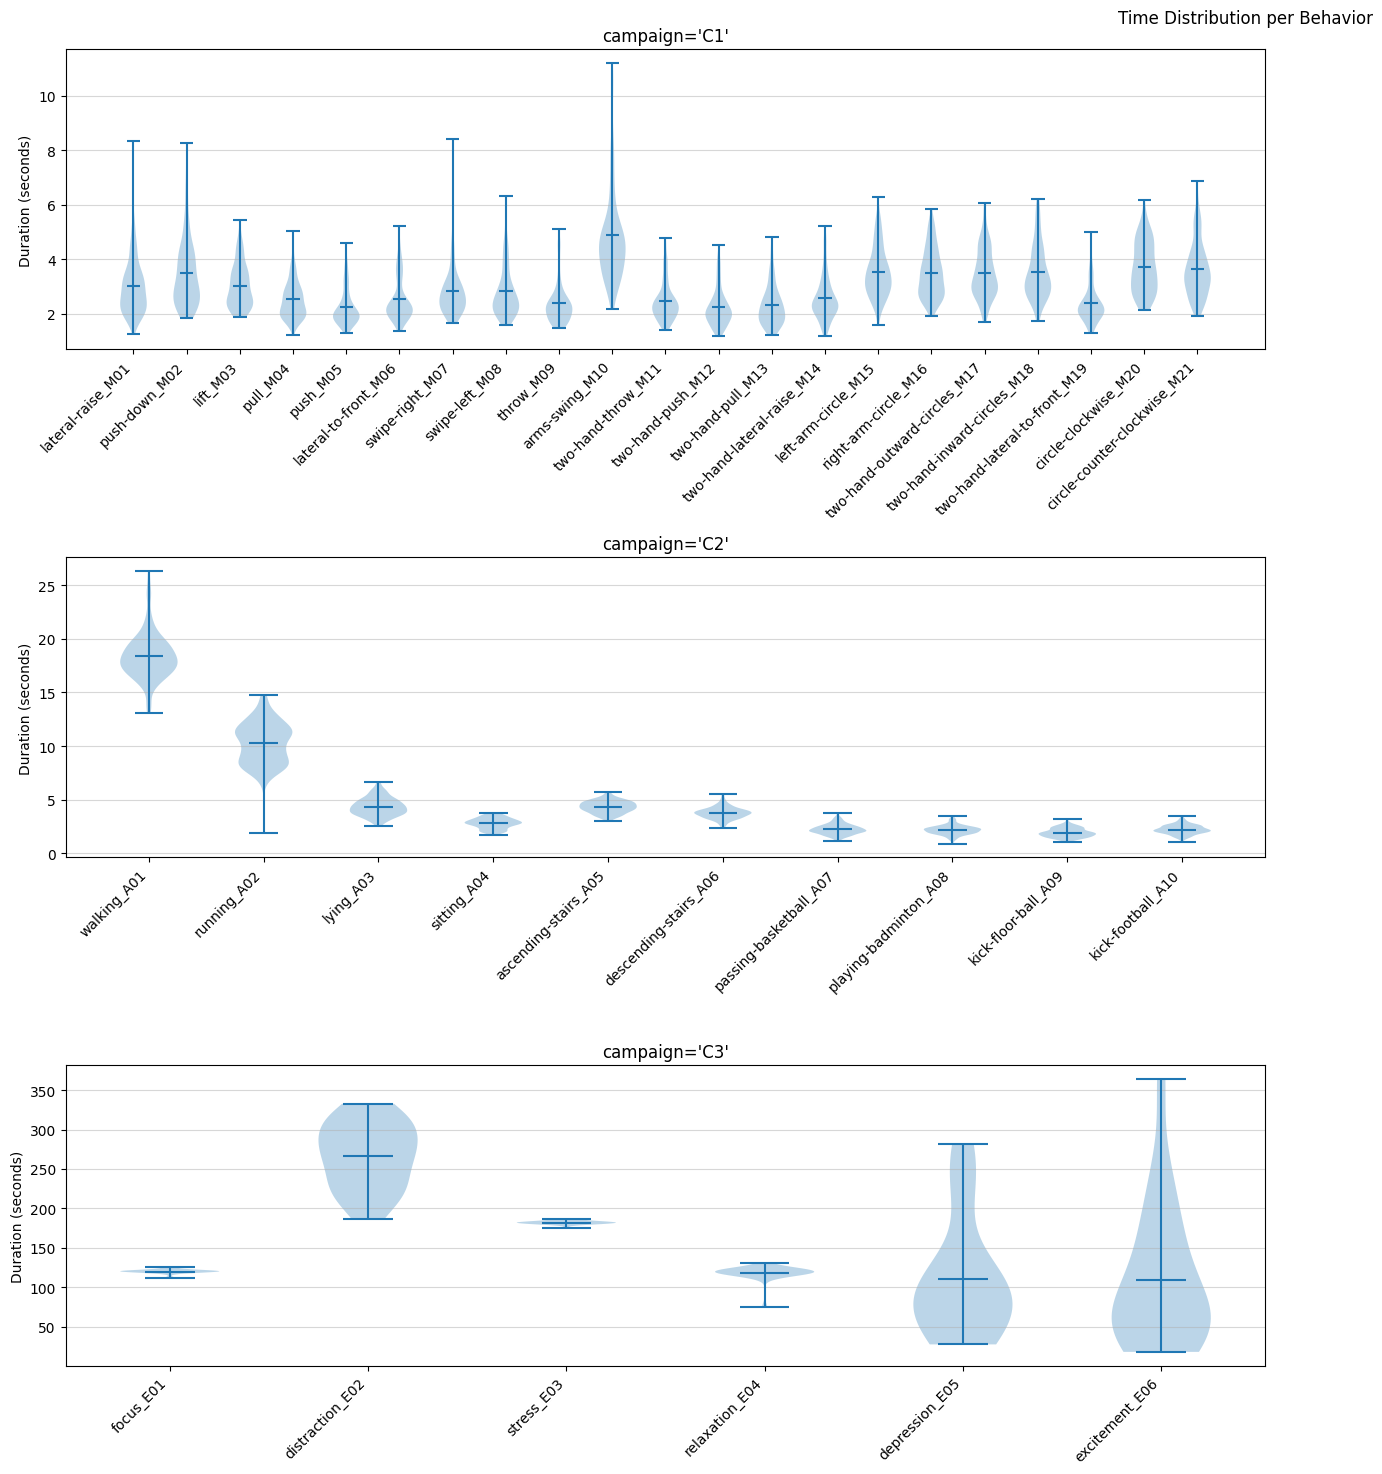

In [7]:
plt.figure(figsize=(25, 15))
sensors = ["mean", "radar", "infrared"]
plt.suptitle("Time Distribution per Behavior")
for i, campaign in enumerate(df.campaign.unique()):
    for j, sensor in enumerate(sensors[:1]):
        plt.subplot(3, 2, i*2 + j + 1)
        behaviors = df[df.campaign==campaign].behavior.unique()
        counts_per_behavior = [df[df.behavior==b][f"{sensor}_duration"].dropna() for b in behaviors]
        plt.violinplot(counts_per_behavior, showmeans=True)
        plt.title(f"{campaign=}")
        plt.xticks(ticks=range(1, len(behaviors)+1), labels=[N.map_to_name(b)+"_"+b for b in behaviors], rotation=45, ha="right")
        plt.ylabel("Duration (seconds)")
        plt.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.show()

## performance against n_params

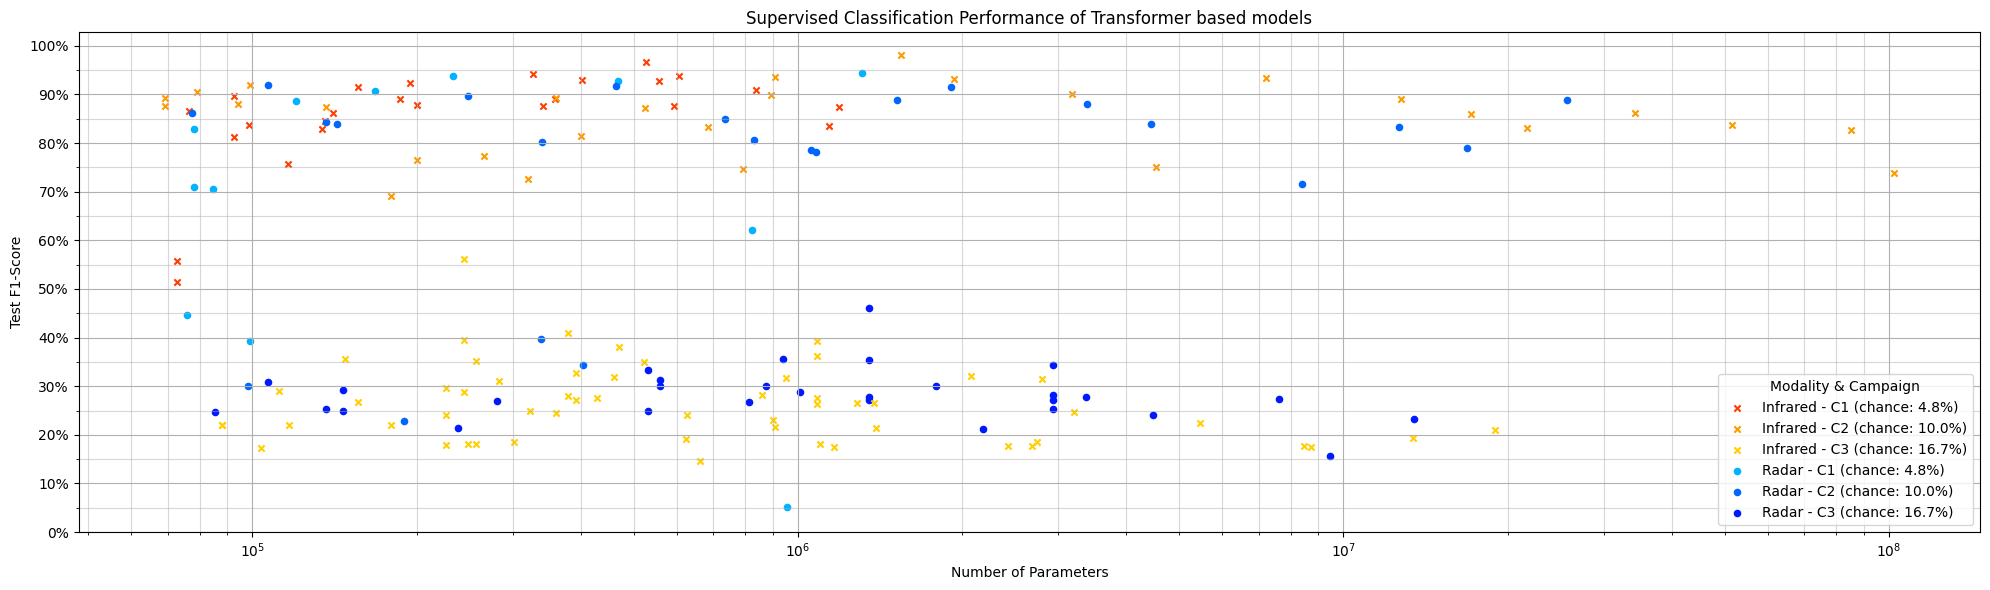

In [151]:
plt.figure(figsize=(20, 6))
for i, (n_cls, r_c, ir_c) in enumerate([(21, 0.55, 0.04), (10, 0.6, 0.10), (6, 0.65, 0.135)]):
    cls_df = pd.read_json(f"experiments/{n_cls}_class_experiment_logs.jsonl", lines=True)
    mask = cls_df["model_type"] == "radar"
    plt.scatter(cls_df[ mask]["n_params"], cls_df[ mask]["test_f1"], color=hsv_to_rgb( r_c, 1, 1), marker="o", s=20, label=f"Radar - C{i+1} (chance: {1/n_cls:.1%})")
    plt.scatter(cls_df[~mask]["n_params"], cls_df[~mask]["test_f1"], color=hsv_to_rgb(ir_c, 1, 1), marker="x", s=20, label=f"Infrared - C{i+1} (chance: {1/n_cls:.1%})")
    # break
plt.xlabel("Number of Parameters")
plt.ylabel("Test F1-Score")
yticks = np.arange(0, 1.05, 0.05)
plt.yticks(yticks, minor=True)
yticks = np.arange(0, 1.05, 0.1)
plt.yticks(yticks, labels=[f"{t:.0%}" for t in yticks], minor=False)
plt.xscale("log")
plt.grid(True)
plt.grid(True, which="minor", alpha=0.5)
legend = plt.legend()
handles, labels = plt.gca().get_legend_handles_labels()
handles, labels = zip(*sorted(zip(handles, labels), key=lambda x: x[1]))
legend = plt.legend(handles, labels, title="Modality & Campaign", loc="lower right", fontsize="medium", title_fontsize="medium")
plt.title("Supervised Classification Performance of Transformer based models")
plt.tight_layout()
plt.show()

In [144]:
exp_df = pd.concat([pd.read_json(f"./experiments/{n_cls}_class_experiment_logs.jsonl", lines=True) for n_cls in [21, 10, 6]], ignore_index=True).reset_index(drop=True)
exp_df["labels"] = exp_df["labels"].apply(lambda x: tuple(x))
exp_df["n_out" ] = exp_df["labels"].apply(len)
best_models = exp_df.sort_values(["n_out", "model_type","test_f1"], ascending=False).groupby(["model_type","n_out"]).head(1)
best_models[['model_type', 'n_out', 'n_params', 'test_f1', 'train_loss', 'valid_loss','model_id']]

,model_type,n_out,n_params,test_f1,train_loss,valid_loss,model_id
5,radar,21,1311125,0.944120,0.161055,0.176886,r{od21pce{es64nh8nl5psM}te{es128nh8nl4psM}}_13...
23,infrared,21,526869,0.965628,0.061718,0.034322,"i{d{hd[64,64]od128}od21te{es64nh4nl5psE}}_5268..."
30,fancy_infrared,21,327365,0.941758,0.106384,0.052455,"fi{d{hd[64,128]od16}od21pce{es32nh32nl3psMupeT..."
74,radar,10,106826,0.919738,0.078454,0.248489,r{od10pce{es32nh16nl3psM}te{es64nh8nl1psM}}_10...
53,infrared,10,909034,0.936344,0.079367,0.201994,"i{d{hd[64,64]od32}id42od10te{es128nh32nl3psE}}..."
62,fancy_infrared,10,1541850,0.981166,0.024664,0.063317,fi{d{hd[16]od32}od10pce{es128nh16nl1psMupeF}te...
142,radar,6,1349766,0.461190,1.177644,1.079361,r{od6pce{es256nh4nl1psM}te{es128nh4nl2psM}}_13...
163,infrared,6,378534,0.409054,0.941139,1.339633,"i{d{hd[128,128]od32}id42od6te{es64nh4nl1psM}}_..."
132,fancy_infrared,6,243798,0.561636,1.082903,1.229567,"fi{d{hd[64,128]od16}od6pce{es32nh8nl2psMupeT}t..."


Preloading dataset:   0%|          | 0/672 [00:00<?, ?sample/s]

Preloading dataset:   0%|          | 0/672 [00:00<?, ?sample/s]

Preloading dataset:   0%|          | 0/320 [00:00<?, ?sample/s]

Preloading dataset:   0%|          | 0/320 [00:00<?, ?sample/s]

Preloading dataset:   0%|          | 0/24 [00:00<?, ?sample/s]

Preloading dataset:   0%|          | 0/24 [00:00<?, ?sample/s]

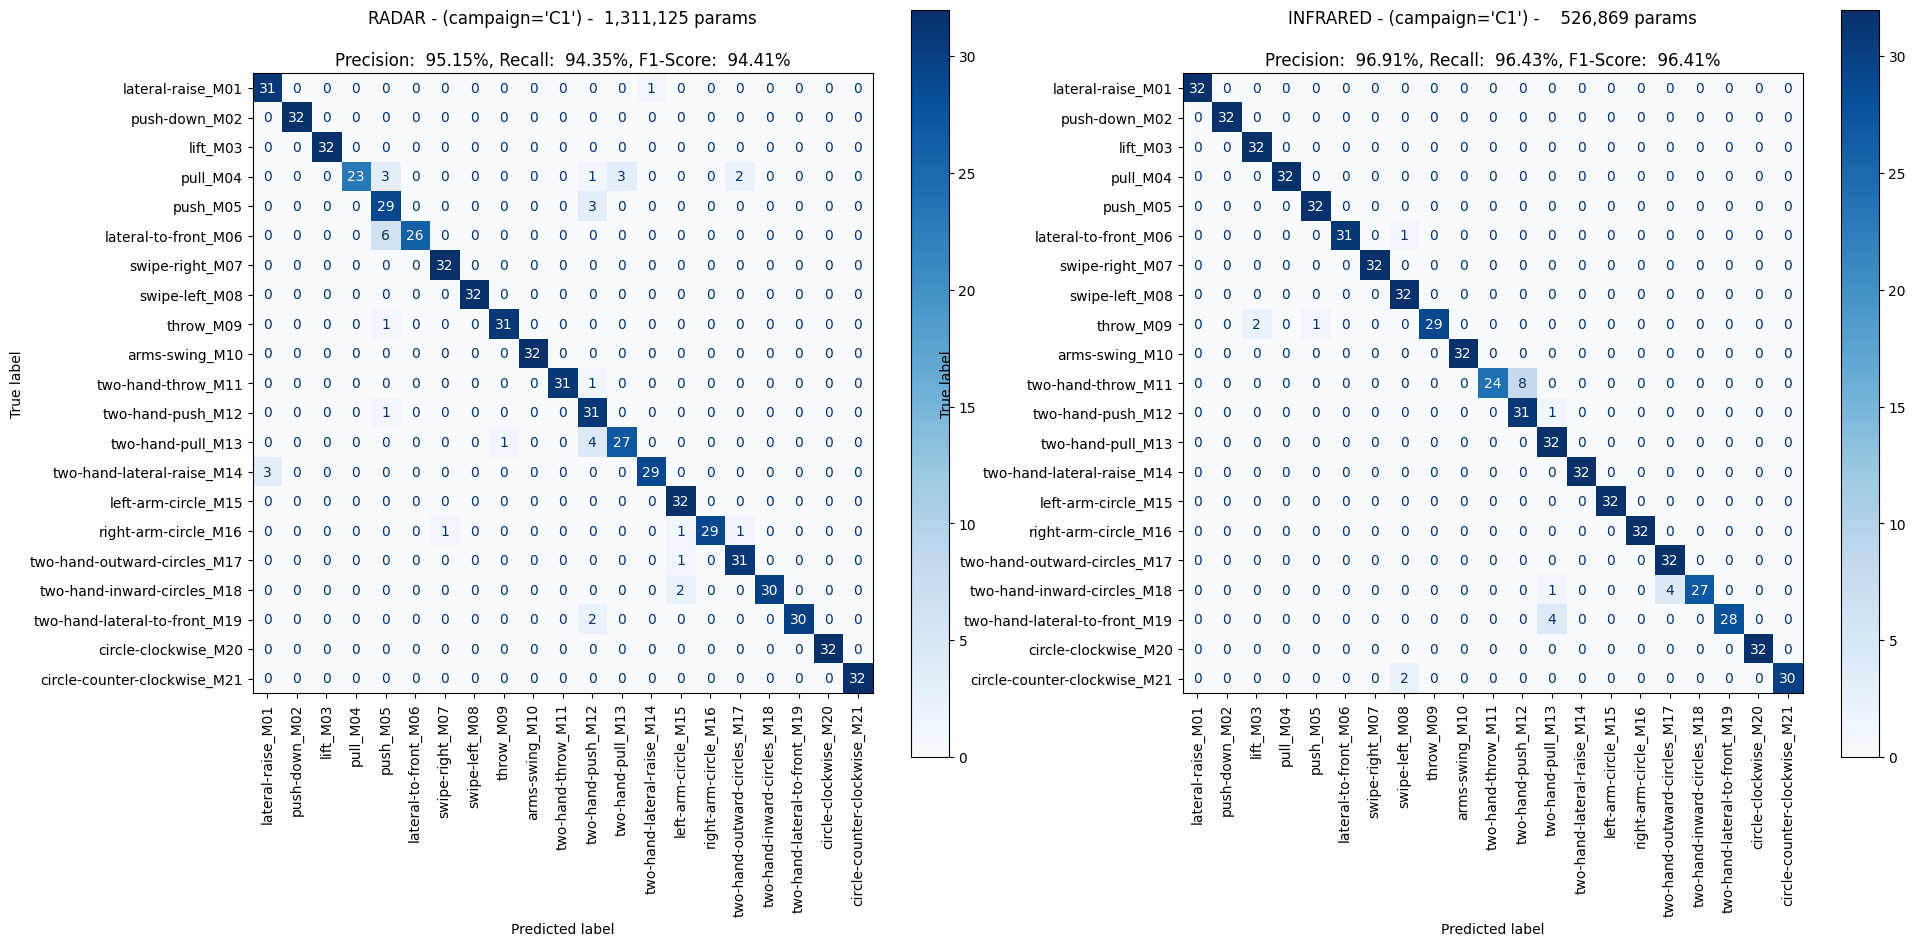

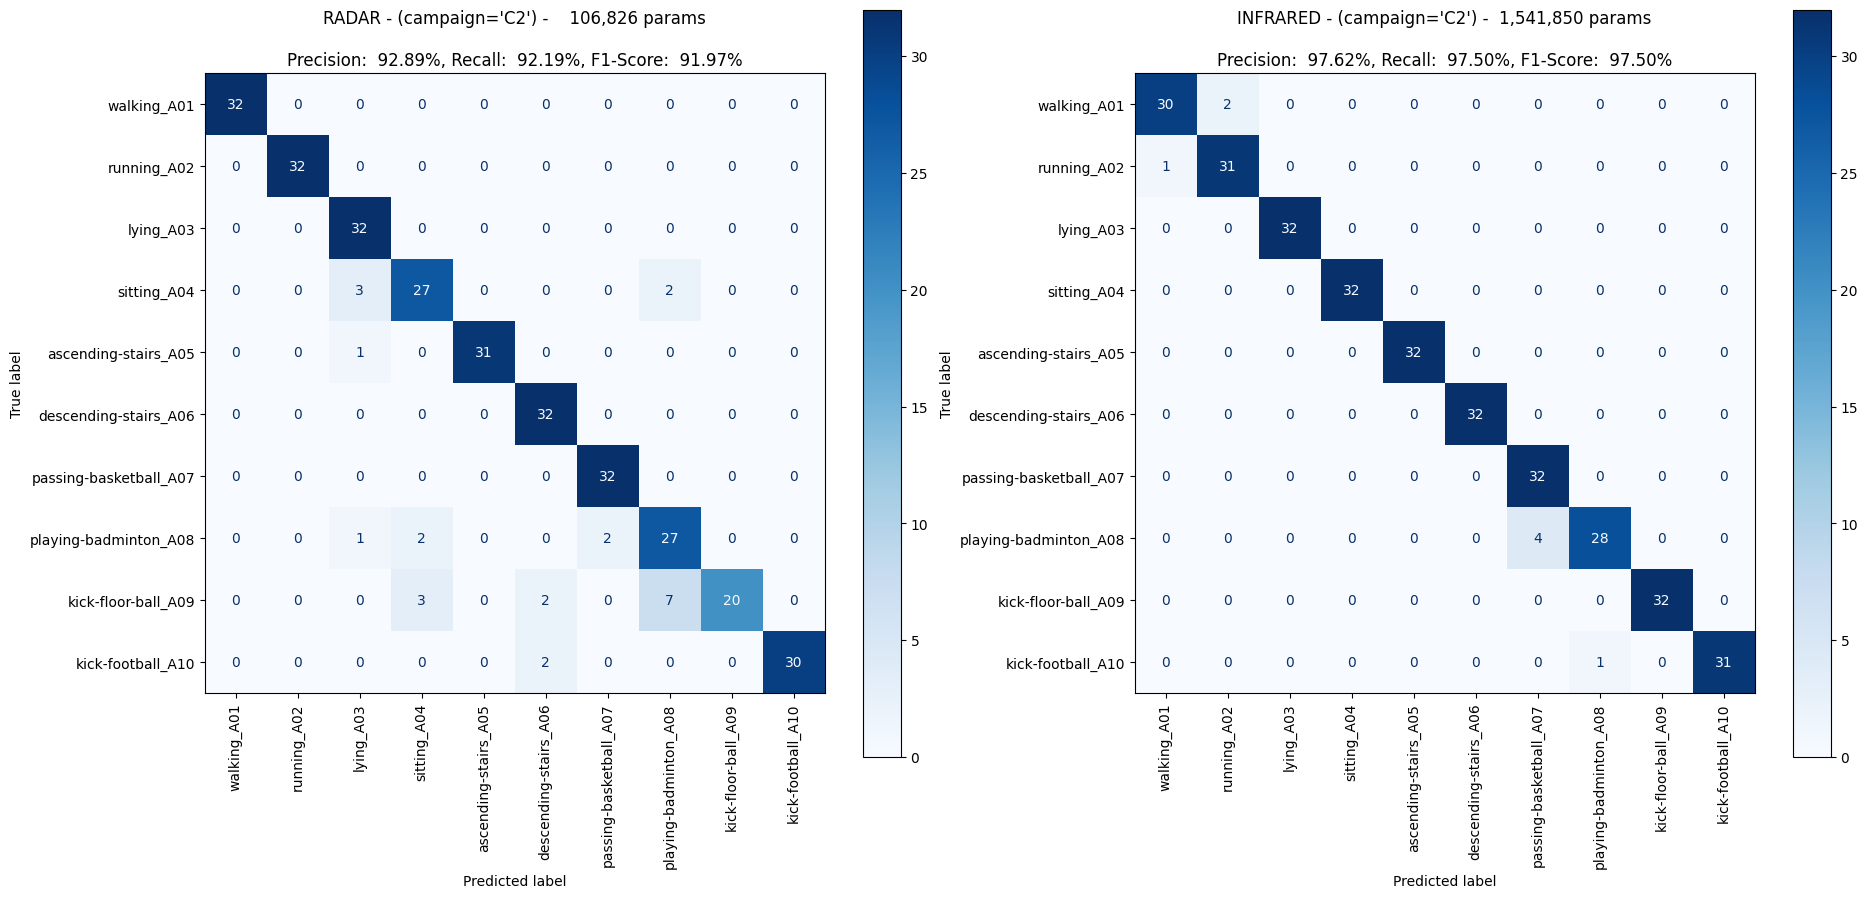

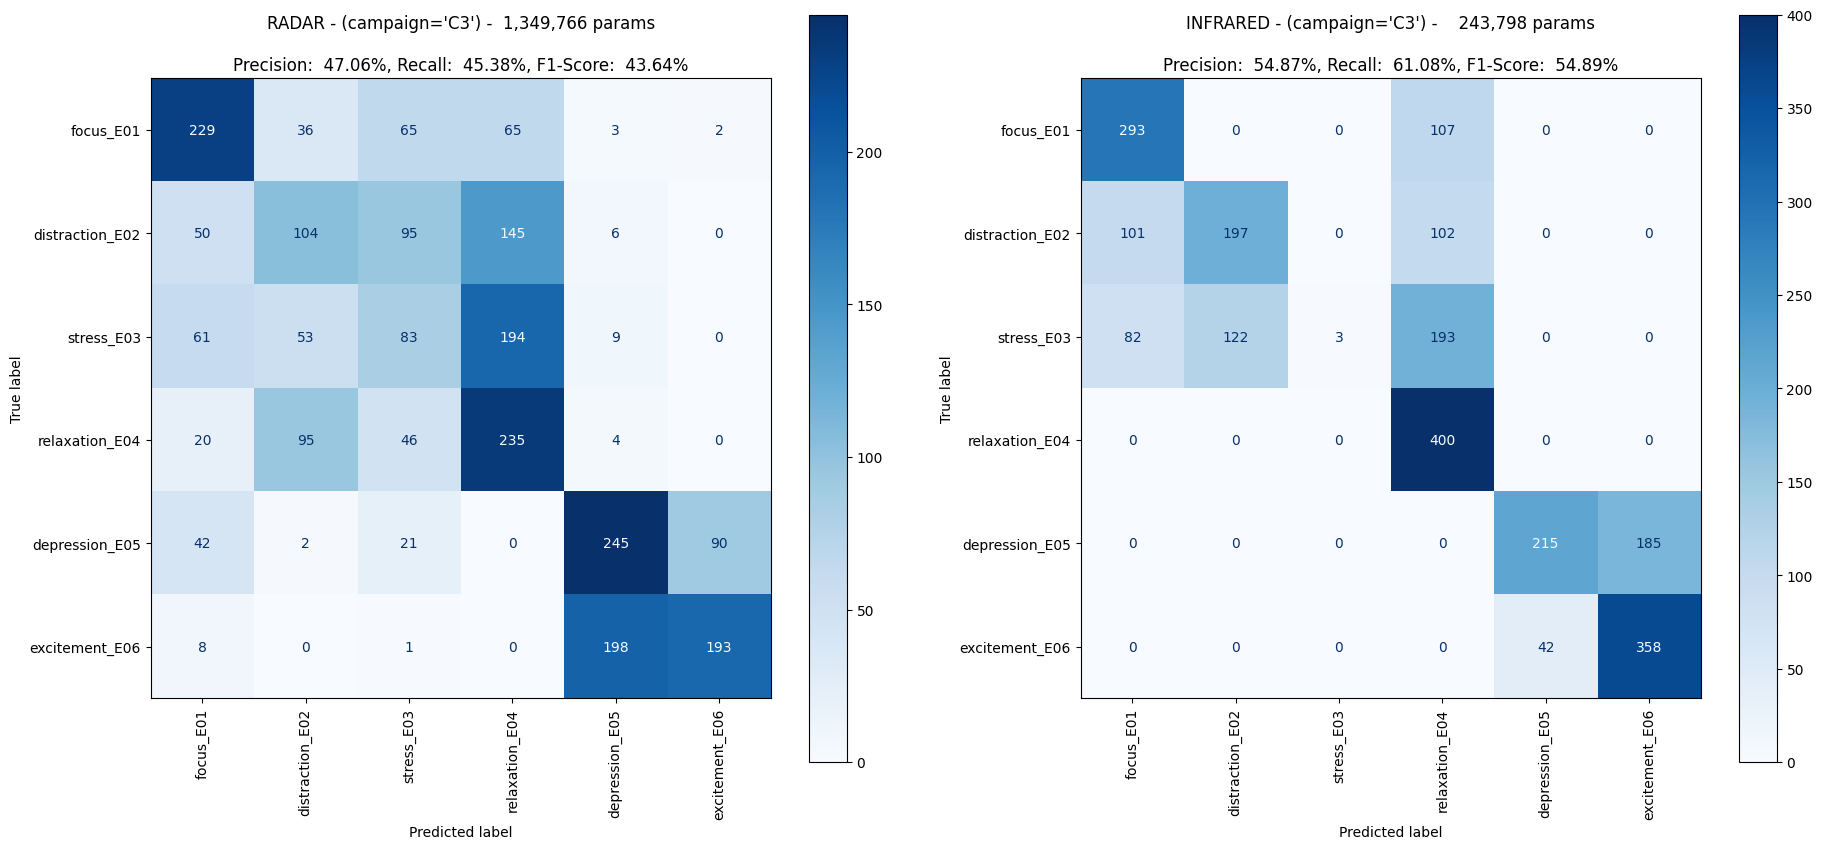

In [150]:
data_df = D.find_available_files("../../../RF-Behavior")
# campaign, n_cls = "C3", 6
for campaign, n_cls in [("C1", 21), ("C2", 10), ("C3", 6)]: # , ("all", 37)
    df = pd.read_json(f"./experiments/{n_cls}_class_experiment_logs.jsonl", lines=True)
    mask = df["labels"].apply(lambda x: len(x) == n_cls)
    df = df[mask]
    df["modality"] = df["model_type"].apply(lambda x: x.split("_")[-1])
    best_models = df.sort_values(["modality", "test_f1"], ascending=[False, False]).groupby(["modality"]).head(1)
    plt.figure(figsize=(22, 33))
    for i, (_, row) in enumerate(best_models.iterrows()):
        model = M.get_model_from_path("experiments/"+row["model_id"]+".pt").eval().to("cuda")
        test_df = data_df[data_df.behavior.isin(row["labels"]) & (data_df.user.isin(row["test_users"]))]
        test_data = D.BehaviorDataset(test_df, modality=row["modality"]).preload()
        test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False, pin_memory=True, num_workers=0, collate_fn=D.BehaviorDataset.collate_fn)
        ys, ps, rs, f1s = {}, [], [], []
        for _ in range(100 if campaign == "C3" else 1):
            p, r, f1 = T.evaluate_model(model, test_loader, device="cuda", ys=ys)
            ps.append(p)
            rs.append(r)
            f1s.append(f1)
        ax = plt.subplot(3, 2, i+1)
        disp = ConfusionMatrixDisplay.from_predictions(ys["targets"], ys["predicted"], display_labels=[N.map_to_name(b)+"_"+b for b in row["labels"]], xticks_rotation=90, cmap="Blues", ax=ax)
        disp.ax_.set_title(f"{row['model_type'].upper().split('_')[-1]} - ({campaign=}) - {row['n_params']:>10,} params\n\n"  # - test_f1={row['test_f1']:.2%}
                        f"Precision: {np.mean(ps):>7.2%}, Recall: {np.mean(rs):>7.2%}, F1-Score: {np.mean(f1s):>7.2%}")
        disp.plot()
        plt.tight_layout()
        plt.close()
plt.show()

## augmentation

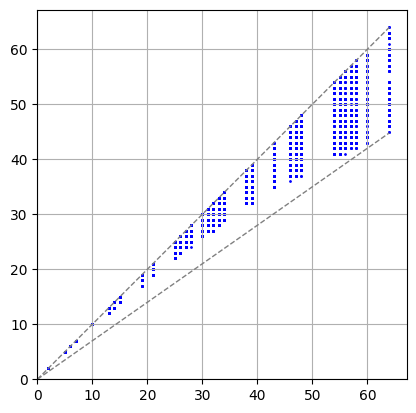

In [ ]:
import matplotlib.pyplot as plt

sample = R.RadarData.read_from_path(glob(os.path.join(DATASET_PATH, "Radar/C1/U01/M01/01/*.pkl"))).bin(18.7)
old_lens = [len(f) for f in sample.frames]
for _ in range(100):
    new_sample = sample.augment_by_points()
    # new_sample = sample.augment_by_rid()
    new_lens = [len(f) for f in new_sample]
    plt.scatter(old_lens, new_lens, s=1, color="blue")

upper = max(max(old_lens), max(new_lens))
plt.plot([0,upper], [0,upper], color="gray", linestyle="--", linewidth=1)
plt.plot([0,upper], [0,upper*0.7], color="gray", linestyle="--", linewidth=1)
plt.xlim(0,upper*1.05)
plt.ylim(0,upper*1.05)
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')